# Product Return Prediction

### 1) Setup & Imports

In [1]:
import os
import random
import csv
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import combinations

import sklearn
from sklearn.metrics import accuracy_score, roc_auc_score

import torch
from torch import nn
from torch_geometric.data import HeteroData, DataLoader
from torch_geometric.datasets import OGB_MAG
from torch_geometric.nn import SAGEConv, to_hetero, HANConv
import torch_geometric.transforms as T
import torch.nn.functional as F
import torch.optim as optim


### 2) Data Loading

In [2]:
task_data = pd.read_csv('task2_data.txt',sep = ',')
train_label = pd.read_csv('task2_train_label.txt',sep = '\t',header = None, names = ['order', 'product', 'label'])
valid_label = pd.read_csv('task2_valid_label.txt',sep = '\t', header = None, names = ['order', 'product', 'label'])
test_query = pd.read_csv('task2_test_query.txt',sep = '\t', header = None, names = ['order', 'product'])

In [3]:
train_data = task_data.merge(train_label, how='inner', on=['order', 'product'])
valid_data = task_data.merge(valid_label, how='inner', on=['order', 'product'])
test_data = task_data.merge(test_query, how='inner', on=['order', 'product']) # no label

1) product_info (reader only)

In [4]:
product_info = defaultdict(int)
for i in tqdm(range(len(train_data))):
  row = train_data.iloc[i,:]
  if product_info[row['product']] == 0:
    product_info[row['product']] = [row['color'],row['size'],row['group']]
  else :
    continue

100%|██████████| 1866383/1866383 [01:22<00:00, 22561.96it/s]


In [9]:
# with open('/data/home/yjkim/datamining_task2/New_data/product_info.csv', 'w') as f:
#     writer = csv.writer(f)    
#     for k,v in product_info.items():
#         writer.writerow([k] + v)

In [5]:
with open('/data/home/yjkim/datamining_task2/New_data/product_info.csv', 'r') as f:
    reader = csv.reader(f)    
    product_info = defaultdict(list)
    for row in reader:
        for i in range(1,len(row)):
            product_info[np.int64(row[0])].append(np.int64(row[i]))

2. order_product_dict (reader only)

In [5]:
order_product_dict = defaultdict(int)
for i in tqdm(range(len(train_data))):
  row = train_data.iloc[i,:]
  if order_product_dict[row['order']] == 0:
    order_product_dict[row['order']] = [row['product']]
  else :
    order_product_dict[row['order']].append(row['product'])
for i in tqdm(range(len(valid_data))):
  row = valid_data.iloc[i,:]
  if order_product_dict[row['order']] == 0:
    order_product_dict[row['order']] = [row['product']]
  else :
    order_product_dict[row['order']].append(row['product'])
for i in tqdm(range(len(test_data))):
  row = test_data.iloc[i,:]
  if order_product_dict[row['order']] == 0:
    order_product_dict[row['order']] = [row['product']]
  else :
    order_product_dict[row['order']].append(row['product'])

100%|██████████| 399939/399939 [00:15<00:00, 25155.96it/s]


In [6]:
with open('/data/home/yjkim/datamining_task2/New_data/order_product_dict.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    for k, v in order_product_dict.items():
        writer.writerow([k] + v)

In [6]:
with open('/data/home/yjkim/datamining_task2/New_data/order_product_dict.csv', 'r') as f:
    reader = csv.reader(f)
    order_product_dict = defaultdict(list)
    for row in reader:
        order_id = int(row[0])
        products = [int(product) for product in row[1:]]
        order_product_dict[order_id].extend(products)

7. customer_info (reader only)

In [8]:
# customer - return 관계
customer_return = defaultdict(int)
for i in tqdm(range(len(train_data))):
  row = train_data.iloc[i,:]
  if customer_return[row['customer']] == 0:
    customer_return[row['customer']] = [row['label']]
  else :
    customer_return[row['customer']].append(row['label'])

for i in tqdm(range(len(valid_data))):
  row = valid_data.iloc[i,:]
  if customer_return[row['customer']] == 0:
    customer_return[row['customer']] = [row['label']]
  else :
    customer_return[row['customer']].append(row['label'])

for i in tqdm(range(len(test_data))):
  row = test_data.iloc[i,:]
  if customer_return[row['customer']] == 0:
    customer_return[row['customer']] = [0] #no label
  else :
    customer_return[row['customer']].append(0)

100%|██████████| 399939/399939 [00:15<00:00, 26193.48it/s]


In [9]:
with open('/data/home/yjkim/datamining_task2/New_data/customer_return.csv', 'w') as f:
    writer = csv.writer(f)    
    for k,v in customer_return.items():
        writer.writerow([k] + v)

In [10]:
with open('/data/home/yjkim/datamining_task2/New_data/customer_return.csv', 'r') as f:
    reader = csv.reader(f)    
    customer_return = defaultdict(list)
    for row in reader:
        for i in range(1,len(row)):
            customer_return[np.int64(row[0])].append(np.int64(row[i]))

In [11]:
customer_return[0]

[1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]

In [12]:
for j in range(342039):
    if type(customer_return[j]) is int or float:
        customer_return[j] = 0
    else:
        count_zero = customer_return[j].count(0)
        count_one = customer_return[j].count(1)
        length = count_one+count_zero
        customer_return[j] = count_one / length

### 3) Feature Engineering

In [8]:
# customer 의 feature를 bought unique product num 으로 주기
customer_info = defaultdict(int)
for i in tqdm(range(len(train_data))):
  row = train_data.iloc[i,:]
  if customer_info[row['customer']] == 0:
    customer_info[row['customer']] = [row['product']]
  else :
    customer_info[row['customer']].append(row['product'])
for i in tqdm(range(len(valid_data))):
  row = valid_data.iloc[i,:]
  if customer_info[row['customer']] == 0:
    customer_info[row['customer']] = [row['product']]
  else :
    customer_info[row['customer']].append(row['product'])
for i in tqdm(range(len(test_data))):
  row = test_data.iloc[i,:]
  if customer_info[row['customer']] == 0:
    customer_info[row['customer']] = [row['product']]
  else :
    customer_info[row['customer']].append(row['product'])

100%|██████████| 399939/399939 [00:15<00:00, 25307.90it/s]


In [14]:
with open('/data/home/yjkim/datamining_task2/New_data/customer_info.csv', 'w') as f:
    writer = csv.writer(f)    
    for k,v in customer_info.items():
        writer.writerow([k] + v)

In [13]:
with open('/data/home/yjkim/datamining_task2/New_data/customer_info.csv', 'r') as f:
    reader = csv.reader(f)    
    customer_info = defaultdict(list)
    for row in reader:
        customer_id = np.int64(row[0])
        products = [np.int64(product) for product in row[1:]]
        customer_info[customer_id].extend(products)

In [14]:
customer_feature_dict = defaultdict()
for i in range(342039):
    onehot = [0]*500
    if len(customer_info[i]) > 500:
        onehot[-1] += 1
    else:
      onehot[len(customer_info[i])] += 1
    customer_feature_dict[i] = onehot + [customer_return[i]]
customer_x = [customer_feature_dict[key] for key in sorted(customer_feature_dict.keys())]

In [10]:
# Define the embedding layer
embedding_size = 50  # The size of the dense vector
num_customers = 342039  # Total number of unique customer IDs

embedding = nn.Embedding(num_customers, embedding_size)

customer_ids = torch.arange(0, num_customers)
embedded_ids = embedding(customer_ids)
customer_x = embedded_ids

### 4) Graph Construction

In [15]:
import networkx as nx
from networkx import pagerank

G = nx.Graph()

for key, value in tqdm(order_product_dict.items()):
  p_list = value
  combi = combinations(p_list,2)
  for c in combi:
    if G.has_edge(c[0], c[1]):
      G[c[0]][c[1]]['weight'] += 1
    else :
      G.add_edge(c[0], c[1], weight = 1)

100%|██████████| 849185/849185 [00:08<00:00, 99793.97it/s] 


In [16]:
page_rank = pagerank(G, max_iter = 100, weight = 'weight')

page_rank_max = np.max(list(page_rank.values()))
page_rank_min = np.min(list(page_rank.values()))
page_rank_mean = np.mean(list(page_rank.values()))

scaled_page_rank = defaultdict()
for i in range(58415):
  if i in page_rank:
    scaled_page_rank[i] = (page_rank[i]-page_rank_min)/(page_rank_max-page_rank_min)
  else:
    scaled_page_rank[i] = page_rank_mean

scaled_page_rank = [scaled_page_rank[key] for key in sorted(scaled_page_rank.keys())]

#### Data preparation

In [17]:
product_idx = sorted(list(set(train_data['product'].values.tolist() + valid_data['product'].values.tolist() + test_data['product'].values.tolist()))) #product from all data / product id
product_x = []
for idx in product_idx:
    onehot = [0]*32
    onehot2 = [0]*29
    onehot3 = [0]*65

    group_info = product_info[idx][2] # group
    size_info = product_info[idx][1] # size
    color_info = product_info[idx][0] # color

    onehot[group_info] += 1
    onehot2[size_info] += 1
    onehot3[color_info//10] += 1

    product_page_rank = scaled_page_rank[idx]
    product_x.insert(idx, onehot+onehot2+onehot3+[product_page_rank]) # idx에 onehot+pagerank 삽입

edge_source = [] #product_order_pair-product
edge_destination = []

product_edge_source = [] #product-product
product_edge_destination = []

product_customer_source = [] #customer - product
product_customer_destination = []

product_order_y = []
product_order_x = []

# train set에서
tmp = None
product_idx = 0
for _, row in tqdm(train_data.iterrows()):
  order = row['order']
  label = row['label']
  product = row['product']
  size = row['size']
  group = row['group']
  color = row['color']
  customer = row['customer']

  p_list = order_product_dict[order] # order 별 product list
  #product_feature = product_info[product] # color, group, size
  onehot_g = [0]*32
  onehot_s = [0]*29
  onehot_c = [0]*65
  onehot_c[color//10] += 1
  onehot_g[group] += 1
  onehot_s[size] += 1
  onehot_p = [0]*30 # len of product list
  if len(p_list) >= 30:
    onehot_p[29] += 1
  else:
    onehot_p[len(p_list)-1] += 1


  concatenated_vector = np.concatenate((onehot_g, onehot_s, onehot_c, onehot_p, [scaled_page_rank[product]]))
  product_order_x.append(concatenated_vector) # main node : product-order node #group,color,size + num of product list
  product_order_y.append([label]) # 0 or 1 label

  edge_source.append(product_idx)
  product_customer_source.append(product_idx)
  product_idx += 1
  edge_destination.append(product) # product id 
  product_customer_destination.append(customer) # customer id
  
  if tmp != p_list:
    combi = combinations(p_list,2)
    for c in combi:
      product_edge_source.append(c[0])
      product_edge_destination.append(c[1])
  tmp = p_list
train_num = len(product_order_y)

# valid set에서
for _, row in tqdm(valid_data.iterrows()):
  order = row['order']
  label = row['label']
  product = row['product']
  size = row['size']
  group = row['group']
  color = row['color']
  customer = row['customer']

  p_list = order_product_dict[order]
  
  onehot_g = [0]*32
  onehot_s = [0]*29
  onehot_c = [0]*65
  onehot_c[color//10] += 1
  onehot_g[group] += 1
  onehot_s[size] += 1
  onehot_p = [0]*30 # len of product list
  if len(p_list) >= 30:
    onehot_p[29] += 1
  else:
    onehot_p[len(p_list)-1] += 1

  concatenated_vector = np.concatenate((onehot_g, onehot_s, onehot_c, onehot_p, [scaled_page_rank[product]]))
  product_order_x.append(concatenated_vector) # main node : product-order node #group,color,size + num of product list
  product_order_y.append([label])

  edge_source.append(product_idx)
  product_customer_source.append(product_idx)
  product_idx += 1
  edge_destination.append(product) # product id 
  product_customer_destination.append(customer) # customer id
  
  if tmp != p_list:
    combi = combinations(p_list,2)
    for c in combi:
      product_edge_source.append(c[0])
      product_edge_destination.append(c[1])
  tmp = p_list

val_num = len(product_order_y) - train_num

# test set에서
for _, row in tqdm(test_data.iterrows()):
  order = row['order']
  product = row['product']
  size = row['size']
  group = row['group']
  color = row['color']
  customer = row['customer']

  p_list = order_product_dict[order]
  
  onehot_g = [0]*32
  onehot_s = [0]*29
  onehot_c = [0]*65
  onehot_c[color//10] += 1
  onehot_g[group] += 1
  onehot_s[size] += 1
  onehot_p = [0]*30 # len of product list
  if len(p_list) >= 30:
    onehot_p[29] += 1
  else:
    onehot_p[len(p_list)-1] += 1

  concatenated_vector = np.concatenate((onehot_g, onehot_s, onehot_c, onehot_p, [scaled_page_rank[product]]))
  product_order_x.append(concatenated_vector) # main node : product-order node #group,color,size + num of product list
  product_order_y.append([0]) 

  edge_source.append(product_idx)
  product_customer_source.append(product_idx)
  product_idx += 1
  edge_destination.append(product) # product id 
  product_customer_destination.append(customer) # customer id
  
  if tmp != p_list:
    combi = combinations(p_list,2)
    for c in combi:
      product_edge_source.append(c[0])
      product_edge_destination.append(c[1])
  tmp = p_list

test_num = len(product_order_y) - train_num - val_num
  

1866383it [02:00, 15470.75it/s]
399940it [00:28, 14234.14it/s]
399939it [00:22, 17522.19it/s]


In [8]:
# 이전 version
customer_info = {i: [i] for i in range(342039)}

customer_x = []
customer_ids = list(customer_info.keys())
# print(customer_ids)
num_customers = len(customer_ids)
customer_index_mapping = {cust_id: idx for idx, cust_id in enumerate(customer_ids)}

embedding_dim = 50  # Dimension of the embedding vector
embedding_layer = nn.Embedding(num_customers, embedding_dim)

customer_indices = [customer_index_mapping[cust_id] for cust_id in customer_ids]
customer_indices_tensor = torch.tensor(customer_indices)
customer_embeddings = embedding_layer(customer_indices_tensor)
customer_embeddings = customer_embeddings.clone().detach().type(torch.float)

print(customer_embeddings.shape)

product_customer_source = [] #customer - product
product_customer_destination = []

# train, valid, test data
for index, row in tqdm(train_data.drop_duplicates(subset = 'customer').iterrows()):
  order = row['order']
  p_list = order_product_dict[order]
  customer = row['customer']
  # customer_idx = customer_index_mapping[row['customer']]
  for p in p_list:
    product_customer_source.append(customer) #customer id
    product_customer_destination.append(p) #product id

for customer_idx in tqdm(valid_data.drop_duplicates(subset = 'customer')['customer'].tolist()):
  customer_df = valid_data.loc[valid_data['customer'] == customer_idx]
  p_list = customer_df['product'].tolist()
  for p in p_list:
    product_customer_source.append(customer_idx)
    product_customer_destination.append(p)

for customer_idx in tqdm(test_data.drop_duplicates(subset = 'customer')['customer'].tolist()):
  customer_df = test_data.loc[test_data['customer'] == customer_idx]
  p_list = customer_df['product'].tolist()
  for p in p_list:
    product_customer_source.append(customer_idx)
    product_customer_destination.append(p)

torch.Size([342039, 50])


311985it [00:09, 33831.85it/s]
100%|██████████| 169325/169325 [01:08<00:00, 2474.05it/s]


In [18]:
# data 정의
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = HeteroData()
data['product_order'].x = torch.tensor(product_order_x).type(torch.float)
data['product'].x = torch.tensor(product_x).type(torch.float) # feature: group
data['customer'].x = torch.tensor(customer_x).type(torch.float)

data['product_order'].y = torch.tensor(product_order_y).type(torch.float)
data['product_order','with','product'].edge_index = torch.tensor([edge_source,edge_destination], dtype=torch.long)
data['product_order','with','customer'].edge_index = torch.tensor([product_customer_source, product_customer_destination], dtype=torch.long)
data['product','same_order','product'].edge_index = torch.tensor([product_edge_source,product_edge_destination], dtype=torch.long)

data = T.ToUndirected()(data)
data = T.NormalizeFeatures()(data) # 안하면 학습이 잘 안됨

data['product_order'].train_mask = torch.zeros(data['product_order'].num_nodes, dtype=torch.bool)
data['product_order'].train_mask[:train_num] = 1
data['product_order'].val_mask = torch.zeros(data['product_order'].num_nodes, dtype=torch.bool)
data['product_order'].val_mask[train_num:train_num+val_num] = 1
data['product_order'].test_mask = torch.zeros(data['product_order'].num_nodes, dtype=torch.bool)
data['product_order'].test_mask[train_num+val_num:] = 1

/tmp/ipykernel_3005897/1428994405.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:274.)
  data['product_order'].x = torch.tensor(product_order_x).type(torch.float)


In [19]:
data

HeteroData(
  product_order={
    x=[2666262, 157],
    y=[2666262, 1],
    train_mask=[2666262],
    val_mask=[2666262],
    test_mask=[2666262],
  },
  product={ x=[58415, 127] },
  customer={ x=[342039, 501] },
  (product_order, with, product)={ edge_index=[2, 2666262] },
  (product_order, with, customer)={ edge_index=[2, 2666262] },
  (product, same_order, product)={ edge_index=[2, 9090776] },
  (product, rev_with, product_order)={ edge_index=[2, 2666262] },
  (customer, rev_with, product_order)={ edge_index=[2, 2666262] }
)

In [40]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [30]:
torch.cuda.is_available()
torch.cuda.set_device(1)
torch.cuda.current_device()

1

In [31]:
import gc
gc.collect()
torch.cuda.empty_cache()

### 5) Model Definition

In [26]:
class GNN(torch.nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), 32)
        self.conv2 = SAGEConv((-1, -1), 32)
        self.linear = torch.nn.Linear(32, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        x = self.linear(x)
        x = F.sigmoid(x)
        
        return x


model = GNN(out_channels=1)
model = to_hetero(model, data.metadata(), aggr='sum')
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = torch.device('cpu')
data, model = data.to(device), model.to(device)
print(device)

cuda


### 6) Training & Evaluation

In [ ]:
from torch_geometric.nn import GATConv

class GNN(torch.nn.Module):
    def __init__(self, out_channels, num_heads=2):
        super().__init__()
        self.conv1 = GATConv((-1, -1), 16, heads=num_heads, concat=True, dropout=0.3)
        self.conv2 = GATConv(16 * num_heads, 16, heads=1, concat=True, dropout=0.3)
        self.linear = torch.nn.Linear(16, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.linear(x)
        x = F.sigmoid(x)
        
        return x


model = GNN(out_channels=1)
model = to_hetero(model, data.metadata(), aggr='sum')
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = torch.device('cpu')
data, model = data.to(device), model.to(device)
print(device)

In [27]:
import time
import copy

losses = []
training_accuracies = []
validation_accuracies = []
training_roc = []
validation_roc = []
max_val_epoch_save = 0

def test(mask):
  model.eval()
  pred = np.array(model(data.x_dict, data.edge_index_dict)['product_order'][mask].detach().cpu())
  prediction = np.where(pred >= 0.5, 1,0)

  answer= np.array(data['product_order'].y[mask].detach().cpu())
  acc = accuracy_score(answer,prediction)
  roc_auc = roc_auc_score(answer,pred)
  return float(acc), float(roc_auc)

def train_model(model, num_epochs=1000):
    """
    model: model to train
    dataloaders: train, val, test data's loader
    criterion: loss function
    optimizer: optimizer to update your model
    """
    since = time.time()
    max_val_acc = 0
    max_val_epoch = 0
    early_stopping = 0
    gc.collect()
    for epoch in range(num_epochs):
        if early_stopping >= 100 :
          print('Early stopped')
          break
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        model.train()            # Set model to training mode
        optimizer.zero_grad()

        out = model(data.x_dict, data.edge_index_dict)
        mask = data['product_order'].train_mask
        loss = F.binary_cross_entropy(out['product_order'][mask], data['product_order'].y[mask])

        loss.backward()
        optimizer.step()

        train_acc, train_roc = test(data['product_order'].train_mask)
        val_acc, val_roc = test(data['product_order'].val_mask)
        if val_acc > max_val_acc:
          max_val_acc = val_acc
          max_val_epoch = epoch
          max_val_epoch_save = epoch
          torch.save(model, 'product_best_model.pt')
          early_stopping = 0
        else :
          early_stopping += 1

        losses.append(loss)
        training_accuracies.append(train_acc)
        validation_accuracies.append(val_acc)
        training_roc.append(train_roc)
        validation_roc.append(val_roc)

        print('Loss: {:.4f}'.format(float(loss)))
        print('Train Accuracy: {:.4f}, Train roc : {:.4f}'.format(train_acc,train_roc))
        print('Validation Accuracy: {:.4f}, Valid roc : {:.4f}'.format(val_acc, val_roc))

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('best_val_acc: '+str(max_val_acc)+' at epoch: '+str(max_val_epoch))

train_model(model,300)


Epoch 0/749
----------
Loss: 0.6961
Train Accuracy: 0.4760, Train roc : 0.5114
Validation Accuracy: 0.4853, Valid roc : 0.5105

Epoch 1/749
----------
Loss: 0.6948
Train Accuracy: 0.4775, Train roc : 0.5303
Validation Accuracy: 0.4865, Valid roc : 0.5289

Epoch 2/749
----------
Loss: 0.6937
Train Accuracy: 0.5224, Train roc : 0.5482
Validation Accuracy: 0.5231, Valid roc : 0.5464

Epoch 3/749
----------
Loss: 0.6927
Train Accuracy: 0.5453, Train roc : 0.5640
Validation Accuracy: 0.5372, Valid roc : 0.5617

Epoch 4/749
----------
Loss: 0.6918
Train Accuracy: 0.5304, Train roc : 0.5772
Validation Accuracy: 0.5216, Valid roc : 0.5746

Epoch 5/749
----------
Loss: 0.6911
Train Accuracy: 0.5257, Train roc : 0.5878
Validation Accuracy: 0.5163, Valid roc : 0.5851

Epoch 6/749
----------
Loss: 0.6905
Train Accuracy: 0.5245, Train roc : 0.5963
Validation Accuracy: 0.5151, Valid roc : 0.5934

Epoch 7/749
----------
Loss: 0.6901
Train Accuracy: 0.5241, Train roc : 0.6029
Validation Accuracy: 0.51

In [ ]:
max_val_epoch_save

In [82]:
import os

# Get the current process ID
pid = os.getpid()

print("Current Process ID:", pid)

Current Process ID: 2049804


In [ ]:
model.eval()
out = np.array(model(data.x_dict, data.edge_index_dict)['product_order'].detach().cpu())
p = list(np.where(out >= 0.5, 1,0))
for i in range(2):
  print(p.count(i))

Text(0.5, 1.0, 'Training & validation AUROC')

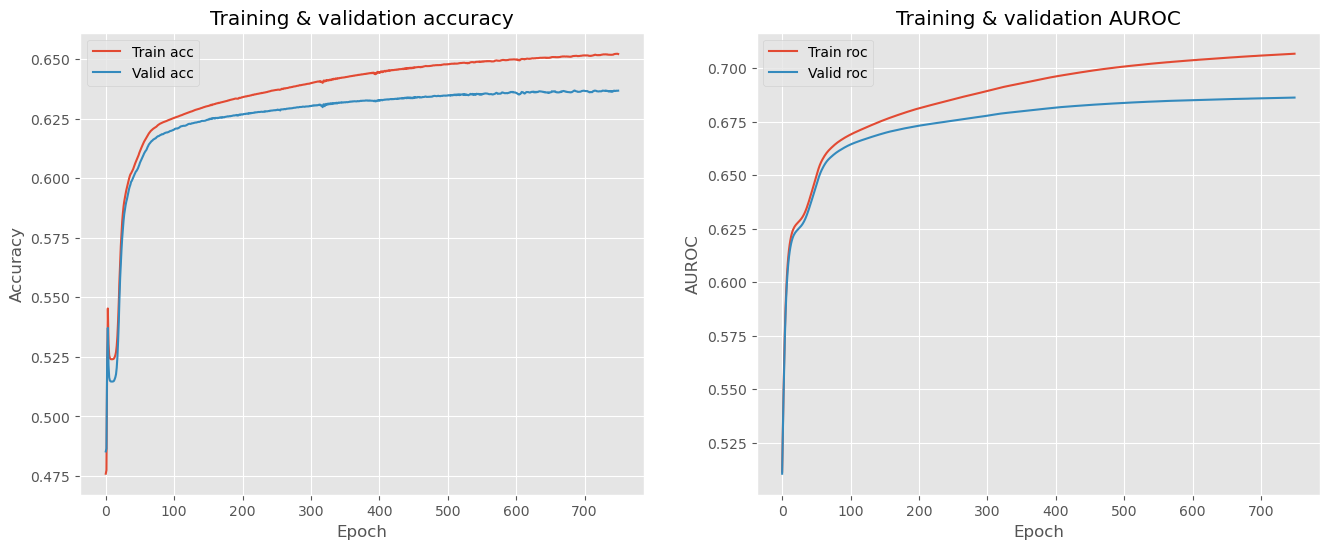

In [28]:
plt.figure(figsize = (16,6))

plt.style.use('ggplot')
x = len(training_accuracies)
plt.subplot(1,2,1)
plt.plot(np.arange(x), training_accuracies, label = 'Train acc')
plt.plot(np.arange(x), validation_accuracies, label = 'Valid acc')

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & validation accuracy')

plt.subplot(1,2,2)
plt.plot(np.arange(x), training_roc, label = 'Train roc')
plt.plot(np.arange(x), validation_roc, label = 'Valid roc')

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('AUROC')
plt.title('Training & validation AUROC')

In [ ]:
model = torch.load('product_best_model.pt')
model.eval()
with torch.no_grad():
  mask = data['product_order'].test_mask
  out  = np.array(model(data.x_dict, data.edge_index_dict)['product_order'][mask].detach().cpu())
  pred = np.squeeze(np.where(out >= 0.5, 1,0)).tolist()


In [63]:
test_query['prediction'] = pred

In [65]:
test_query.to_csv('/data/home/yjkim/datamining_task2/task2_test_prediction.csv', index = False)

In [66]:
test_query

,order,product,prediction
0,72094,18334,0
1,190577,20625,1
2,553037,49439,1
3,420840,33615,1
4,648213,45467,0
...,...,...,...
399934,115842,31870,0
399935,504278,53317,1
399936,144537,33864,1
399937,622382,22404,0


HAN model

In [28]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [17]:
# HAN model

class HAN(nn.Module):
    def __init__(self, dim_in, dim_h=128, dim_fc1=128, dim_fc2=64, out_channels=1, heads=8, dropout=0.4):
        super().__init__()
        self.han = HANConv(dim_in, dim_h, heads=heads, dropout=0.6, metadata=data.metadata())
        self.fc1 = nn.Linear(dim_h, dim_fc1)
        self.fc2 = nn.Linear(dim_fc1, dim_fc2)
        self.fc3 = nn.Linear(dim_fc2, out_channels)
        self.dropout = dropout
        self.batch_norm1 = nn.BatchNorm1d(dim_fc1)
        self.batch_norm2 = nn.BatchNorm1d(dim_fc2)
 
    def forward(self, x_dict, edge_index_dict):
        out = self.han(x_dict, edge_index_dict)
        # Obtain 'product_order' node embeddings
        product_order_logits = out['product_order']

        # Fully connected layers for classification
        x = F.relu(self.fc1(product_order_logits))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.fc3(x)
        
        return torch.sigmoid(x)


# dim_in = data['product_order'].num_node_features  # Set the input dimension
model = HAN(dim_in=-1, out_channels=1)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cpu'
data, model = data.to(device), model.to(device)
print(device)

cuda


In [20]:
# Functions for training and testing
import time
import gc
losses = []
training_accuracies = []
validation_accuracies = []
training_roc = []
validation_roc = []

def test(mask):
    model.eval()
    with torch.no_grad():
        # Obtain predictions only for 'product_order' nodes
        logits = model(data.x_dict, data.edge_index_dict)
        predictions = logits[mask].cpu().numpy()

        # Binary classification thresholding
        pred = np.where(predictions >= 0.5, 1, 0)
        labels = data['product_order'].y[mask].cpu().numpy()

        # Calculate accuracy
        acc = accuracy_score(labels, pred)

        # Calculate ROC-AUC only if both classes are present
        roc_auc = roc_auc_score(labels, predictions)

    return float(acc), float(roc_auc)

def train_model(model, num_epochs=1000):
    since = time.time()
    max_val_acc = 0
    max_val_epoch = 0
    early_stopping = 0
    gc.collect()
    for epoch in range(num_epochs):
        if early_stopping >= 100:
            print('Early stopped')
            break
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        model.train()  # Set model to training mode
        optimizer.zero_grad()

        out = model(data.x_dict, data.edge_index_dict)
        mask = data['product_order'].train_mask
        loss = F.binary_cross_entropy(out[mask], data['product_order'].y[mask])

        loss.backward()
        optimizer.step()

        train_acc, train_roc = test(data['product_order'].train_mask)
        val_acc, val_roc = test(data['product_order'].val_mask)
        if val_acc > max_val_acc:
            max_val_acc = val_acc
            max_val_epoch = epoch
            torch.save(model, 'product_best_model.pt')
            early_stopping = 0
        else:
            early_stopping += 1

        losses.append(loss.item())
        training_accuracies.append(train_acc)
        validation_accuracies.append(val_acc)
        training_roc.append(train_roc)
        validation_roc.append(val_roc)

        print(f'Loss: {float(loss):.4f}')
        print(f'Train Accuracy: {train_acc:.4f}, Train ROC: {train_roc:.4f}')
        print(f'Validation Accuracy: {val_acc:.4f}, Valid ROC: {val_roc:.4f}')
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best validation accuracy at epoch {max_val_epoch}: {max_val_acc:.4f}')


train_model(model, 400)

Epoch 0/399
----------
Loss: 0.6922
Train Accuracy: 0.5240, Train ROC: 0.4944
Validation Accuracy: 0.5147, Valid ROC: 0.4935

Epoch 1/399
----------
Loss: 0.6921
Train Accuracy: 0.5240, Train ROC: 0.5007
Validation Accuracy: 0.5147, Valid ROC: 0.4998

Epoch 2/399
----------
Loss: 0.6921
Train Accuracy: 0.5240, Train ROC: 0.5076
Validation Accuracy: 0.5147, Valid ROC: 0.5066

Epoch 3/399
----------
Loss: 0.6921
Train Accuracy: 0.5240, Train ROC: 0.5144
Validation Accuracy: 0.5147, Valid ROC: 0.5134

Epoch 4/399
----------


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.54 GiB. GPU  has a total capacity of 79.15 GiB of which 708.44 MiB is free. Process 1108792 has 586.00 MiB memory in use. Process 2100945 has 524.00 MiB memory in use. Process 2113444 has 2.87 GiB memory in use. Process 2462375 has 42.42 GiB memory in use. Including non-PyTorch memory, this process has 32.04 GiB memory in use. Of the allocated memory 19.97 GiB is allocated by PyTorch, and 11.58 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)